In [1]:
from datasets import load_dataset
ds = load_dataset("fancyzhx/ag_news")
print(ds)

/Users/vivekjavangula/miniconda3/envs/nlpclf/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [2]:
import pandas as pd

train = ds['train'].to_pandas()
test  = ds['test'].to_pandas()

print(train.shape, test.shape)
print(train.columns.tolist())
print(train['label'].value_counts())
train.head(3)

(120000, 2) (7600, 2)
['text', 'label']
label
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

LABELS = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
train['label_name'] = train['label'].map(LABELS)
test['label_name']  = test['label'].map(LABELS)

# subset for speed — 2000 per class
train_small = (train.groupby('label', group_keys=False)
                    .sample(n=2000, random_state=42)
                    .reset_index(drop=True))

# carve validation out of train — test stays untouched
tr, val = train_test_split(
    train_small, test_size=0.2, stratify=train_small['label'], random_state=42
)

print(tr.shape, val.shape, test.shape)
print(tr['label_name'].value_counts())

(6400, 3) (1600, 3) (7600, 3)
label_name
Business    1600
Sports      1600
Sci/Tech    1600
World       1600
Name: count, dtype: int64


In [4]:
i = pd.DataFrame(tr)
i.head()

,text,label,label_name
5334,Foodland wilts on poor profit outlook Foodland...,2,Business
2926,BASEBALL: JETS ARE FLYING THIS weekend sees th...,1,Sports
7853,Experts Knock E-Vote Data Delay Researchers tr...,3,Sci/Tech
1289,FACTBOX-Profiles of key figures in new Irish c...,0,World
7126,SCO Files for Stay of Execution An anonymous r...,3,Sci/Tech


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

baseline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words='english')),
    ('clf',   LogisticRegression(max_iter=1000))
])

baseline.fit(tr['text'], tr['label'])

val_pred = baseline.predict(val['text'])
print(classification_report(val['label'], val_pred, target_names=list(LABELS.values())))

              precision    recall  f1-score   support

       World       0.91      0.89      0.90       400
      Sports       0.93      0.97      0.95       400
    Business       0.86      0.84      0.85       400
    Sci/Tech       0.87      0.86      0.86       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600



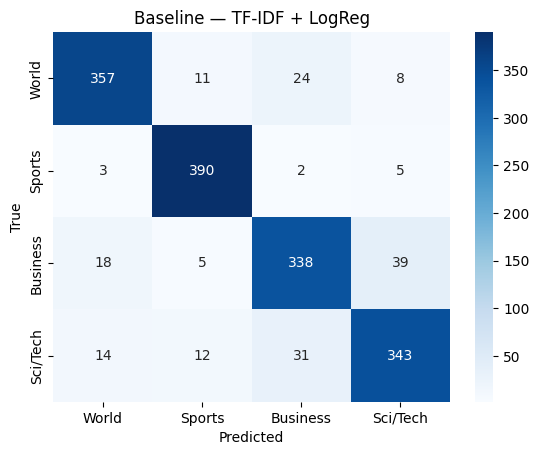

In [6]:
import seaborn as sns, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val['label'], val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS.values(), yticklabels=LABELS.values())
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Baseline — TF-IDF + LogReg')
plt.show()

In [7]:
from sklearn.metrics import f1_score, accuracy_score
baseline_scores = {
    'accuracy': accuracy_score(val['label'], val_pred),
    'macro_f1': f1_score(val['label'], val_pred, average='macro'),
}
print(baseline_scores)

{'accuracy': 0.8925, 'macro_f1': 0.8920669827397003}


In [8]:
import sys; print(sys.executable)
!{sys.executable} -m pip install torch

/Users/vivekjavangula/miniconda3/envs/nlpclf/bin/python


In [9]:
import torch; print(torch.__version__)

2.2.2


In [10]:
from transformers import AutoTokenizer
import numpy as np

MODEL = "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(MODEL)

# check length distribution FIRST — decides max_length
lens = [len(tok(t)['input_ids']) for t in tr['text'].sample(500, random_state=42)]
print(np.percentile(lens, [50, 90, 95, 99]), max(lens))

[ 49.5   69.    78.   123.02] 190


/Users/vivekjavangula/miniconda3/envs/nlpclf/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [11]:
MAX_LEN = 96

def encode(texts):
    return tok(
        list(texts),
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN,
        return_tensors='pt'
    )

enc_tr  = encode(tr['text'])
enc_val = encode(val['text'])

print(enc_tr['input_ids'].shape)
print(enc_tr['attention_mask'].shape)
print(tok.convert_ids_to_tokens(enc_tr['input_ids'][0])[:20])
print(enc_tr['attention_mask'][0][:20])

torch.Size([6400, 96])
torch.Size([6400, 96])
['[CLS]', 'food', '##land', 'wil', '##ts', 'on', 'poor', 'profit', 'outlook', 'food', '##land', 'associated', 'left', 'frustrated', 'investors', 'wanting', 'more', 'yesterday', 'after', 'handing']
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [12]:
import torch
print(torch.__version__)
import transformers
print(transformers.__version__)
from transformers.utils import is_torch_available
print("torch visible to transformers:", is_torch_available())

2.2.2
4.44.2
torch visible to transformers: True


In [13]:
print(enc_tr['attention_mask'][0].sum().item())   # real tokens in this row

36


In [14]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoModelForSequenceClassification

train_ds = TensorDataset(
    enc_tr['input_ids'], enc_tr['attention_mask'],
    torch.tensor(tr['label'].values)
)
val_ds = TensorDataset(
    enc_val['input_ids'], enc_val['attention_mask'],
    torch.tensor(val['label'].values)
)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=64)

model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=4)

device = "mps" if torch.backends.mps.is_available() else "cpu"
model.to(device)
print(device, sum(p.numel() for p in model.parameters()))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


mps 66956548


In [15]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

EPOCHS = 2
optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_dl) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, 0, total_steps)

for epoch in range(EPOCHS):
    model.train()                                  # dropout ON
    running = 0
    for i, (ids, mask, labels) in enumerate(train_dl):
        ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)

        optimizer.zero_grad()                      # 1 clear old grads
        out = model(input_ids=ids, attention_mask=mask, labels=labels)
        loss = out.loss                            # 2+3 forward + loss
        loss.backward()                            # 4 backward
        optimizer.step()                           # 5 update
        scheduler.step()

        running += loss.item()
        if i % 50 == 0:
            print(f"epoch {epoch} step {i}/{len(train_dl)} loss {loss.item():.4f}")

    print(f"epoch {epoch} avg train loss: {running/len(train_dl):.4f}")

epoch 0 step 0/200 loss 1.3749
epoch 0 step 50/200 loss 0.5851
epoch 0 step 100/200 loss 0.2529
epoch 0 step 150/200 loss 0.3410
epoch 0 avg train loss: 0.5090
epoch 1 step 0/200 loss 0.1506
epoch 1 step 50/200 loss 0.1880
epoch 1 step 100/200 loss 0.3590
epoch 1 step 150/200 loss 0.3000
epoch 1 avg train loss: 0.2561


In [16]:
from sklearn.metrics import classification_report, f1_score, accuracy_score

model.eval()                          # dropout OFF
preds, trues = [], []

with torch.no_grad():                 # no gradients = faster, less memory
    for ids, mask, labels in val_dl:
        ids, mask = ids.to(device), mask.to(device)
        logits = model(input_ids=ids, attention_mask=mask).logits
        preds.extend(logits.argmax(-1).cpu().numpy())
        trues.extend(labels.numpy())

print(classification_report(trues, preds, target_names=list(LABELS.values())))

bert_scores = {
    'accuracy': accuracy_score(trues, preds),
    'macro_f1': f1_score(trues, preds, average='macro'),
}
print("baseline:", baseline_scores)
print("distilbert:", bert_scores)

              precision    recall  f1-score   support

       World       0.94      0.90      0.92       400
      Sports       0.97      0.98      0.98       400
    Business       0.86      0.86      0.86       400
    Sci/Tech       0.87      0.90      0.88       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600

baseline: {'accuracy': 0.8925, 'macro_f1': 0.8920669827397003}
distilbert: {'accuracy': 0.91, 'macro_f1': 0.9100371896620886}


In [17]:
import os, json
os.makedirs("models/distilbert", exist_ok=True)

model.save_pretrained("models/distilbert")
tok.save_pretrained("models/distilbert")

json.dump({str(k): v for k, v in LABELS.items()},
          open("models/distilbert/labels.json", "w"))

json.dump({"baseline": baseline_scores, "distilbert": bert_scores},
          open("models/metrics.json", "w"))

print(os.listdir("models/distilbert"))

['labels.json', 'model.safetensors', 'tokenizer_config.json', 'special_tokens_map.json', 'config.json', 'tokenizer.json', 'vocab.txt']


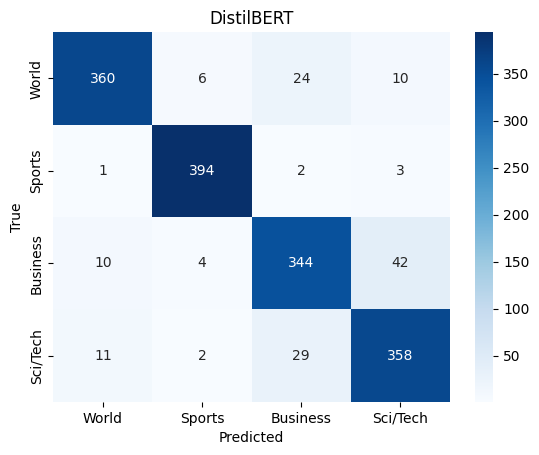

In [18]:
import os
os.makedirs("reports", exist_ok=True)

cm = confusion_matrix(trues, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS.values(), yticklabels=LABELS.values())
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('DistilBERT')
plt.savefig('reports/distilbert_cm.png', dpi=120, bbox_inches='tight')
plt.show()

In [19]:
import os, json, joblib
os.makedirs("models/distilbert", exist_ok=True)

model.save_pretrained("models/distilbert")
tok.save_pretrained("models/distilbert")
json.dump({str(k): v for k, v in LABELS.items()},
          open("models/distilbert/labels.json", "w"))
joblib.dump(baseline, "models/baseline_tfidf_lr.pkl")
json.dump({"baseline": baseline_scores, "distilbert": bert_scores},
          open("models/metrics.json", "w"))
print(os.listdir("models/distilbert"))

['labels.json', 'model.safetensors', 'tokenizer_config.json', 'special_tokens_map.json', 'config.json', 'tokenizer.json', 'vocab.txt']


In [20]:
enc_test = encode(test['text'])
test_ds = TensorDataset(enc_test['input_ids'], enc_test['attention_mask'],
                        torch.tensor(test['label'].values))
test_dl = DataLoader(test_ds, batch_size=64)

model.eval(); tp, tt = [], []
with torch.no_grad():
    for ids, mask, labels in test_dl:
        logits = model(input_ids=ids.to(device), attention_mask=mask.to(device)).logits
        tp.extend(logits.argmax(-1).cpu().numpy()); tt.extend(labels.numpy())

print(classification_report(tt, tp, target_names=list(LABELS.values())))
print("baseline test:", accuracy_score(test['label'], baseline.predict(test['text'])))

              precision    recall  f1-score   support

       World       0.94      0.89      0.91      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.87      0.87      0.87      1900
    Sci/Tech       0.87      0.90      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600

baseline test: 0.8867105263157895


In [21]:
wrong = test.copy()
wrong['pred'] = [LABELS[p] for p in tp]
wrong = wrong[wrong['label_name'] != wrong['pred']]
wrong[['text','label_name','pred']].to_csv("reports/wrong_predictions.csv", index=False)
print(len(wrong))

679


In [22]:
base_test_pred = baseline.predict(test['text'])
print(f1_score(test['label'], base_test_pred, average='macro'))

0.886153601953602


In [23]:
import pandas as pd
wrong = pd.read_csv("reports/wrong_predictions.csv")

print(len(wrong))
print(wrong.groupby(['label_name', 'pred']).size().sort_values(ascending=False).head(10))

679
label_name  pred    
Business    Sci/Tech    182
Sci/Tech    Business    135
World       Business    101
            Sci/Tech     58
            Sports       52
Business    World        51
Sci/Tech    World        48
Sports      World        15
            Business     14
Sci/Tech    Sports       13
dtype: int64


In [24]:
for i in range(15):
    r = wrong.iloc[i]
    print(f"TRUE: {r['label_name']:9} PRED: {r['pred']:9}")
    print(r['text'][:200])
    print("-" * 70)

TRUE: Sci/Tech  PRED: Business 
Rivals Try to Turn Tables on Charles Schwab By MICHAEL LIEDTKE     SAN FRANCISCO (AP) -- With its low prices and iconoclastic attitude, discount stock broker Charles Schwab Corp. (SCH) represented an 
----------------------------------------------------------------------
TRUE: Business  PRED: Sci/Tech 
Retailers Vie for Back-To-School Buyers (Reuters) Reuters - Apparel retailers are hoping their\back-to-school fashions will make the grade among\style-conscious teens and young adults this fall, but i
----------------------------------------------------------------------
TRUE: Sci/Tech  PRED: Business 
Dell Exits Low-End China Consumer PC Market  HONG KONG (Reuters) - Dell Inc. &lt;DELL.O&gt;, the world's  largest PC maker, said on Monday it has left the low-end  consumer PC market in China and cut 
----------------------------------------------------------------------
TRUE: World     PRED: Business 
India's Tata expands regional footprint via NatSteel buy

In [25]:
for i in range(15,25):
    r = wrong.iloc[i]
    print(f"[{i}] TRUE: {r['label_name']:9} PRED: {r['pred']:9}")
    print(r['text'][:180])
    print("-" * 70)

[15] TRUE: World     PRED: Sci/Tech 
Future Doctors, Crossing Borders Students at the Mount Sinai School of Medicine learn that diet and culture shape health in East Harlem.
----------------------------------------------------------------------
[16] TRUE: Sci/Tech  PRED: Business 
Microsoft finalises three-year government deal Hot on the heels of its 10-year strategic partnership with the London Borough of Newham, Microsoft is close to signing a new broad th
----------------------------------------------------------------------
[17] TRUE: World     PRED: Business 
Stock Prices Climb Ahead of Google IPO NEW YORK - Investors shrugged off rising crude futures Wednesday to capture well-priced shares, sending the Nasdaq composite index up 1.6 per
----------------------------------------------------------------------
[18] TRUE: Sci/Tech  PRED: Business 
Intuit Posts Wider Loss After Charge (Reuters) Reuters - Intuit Inc. (INTU.O), maker of\the No. 1 U.S. tax presentation software TurboTax, o

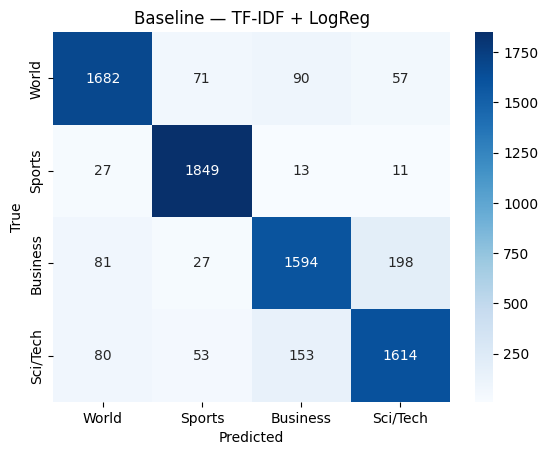

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm_base = confusion_matrix(test['label'], baseline.predict(test['text']))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS.values(), yticklabels=LABELS.values())
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Baseline — TF-IDF + LogReg')
plt.savefig('reports/baseline_cm.png', dpi=120, bbox_inches='tight')
plt.show()